### 不加修改的效果

In [1]:
# import gym
# env = gym.make('CartPole-v0')
# env.reset()
# for _ in range(100):
#     env.render()
#     env.step(env.action_space.sample()) # take a random action
# env.close()

QLearning中更新规则
$$Q(s, a) \leftarrow Q(s, a)+\alpha\left[r+\gamma \max _{a^{\prime} \in \mathcal{A}} Q\left(s^{\prime}, a^{\prime}\right)-Q(s, a)\right]$$
为使时序差分残差$r+\gamma \max _{a^{\prime} \in \mathcal{A}} Q\left(s^{\prime}, a^{\prime}\right)-Q(s, a)$逐渐变小构造均方误差形式的Q网络损失函数：
$$\omega^{*}=\arg \min _{\omega} \frac{1}{2 N} \sum_{i=1}^{N}\left[Q_{\omega}\left(s_{i}, a_{i}\right)-\left(r_{i}+\gamma \max _{a^{\prime}} Q_{\omega}\left(s_{i}^{\prime}, a^{\prime}\right)\right)\right]^{2}$$
括号中前者用目标网络预测一段时间内最佳Q值，后者用“普通”Q网络逐步拟合前者

### 测试一下神经网络的构建

- 现代的神经网络写法中的输入层（可以理解为fc0）和输出层是没有激活函数的，激活函数只定义在隐层内
- 每一层都对之前那一层输入的数据进行一次线性有偏加权平均，隐层在此基础上还用了一次激活函数

In [2]:
# import torch
# import torch.nn.functional as F
# class NN1(torch.nn.Module):
#     ''' 只有一层隐藏层的Q网络 '''
#     def __init__(self, state_dim, hidden_dim, action_dim):
#         super(NN1, self).__init__()
#         self.fc1 = torch.nn.Linear(state_dim, hidden_dim)
#         self.fc2 = torch.nn.Linear(hidden_dim, action_dim)

#     def forward(self, x):
#         x = F.relu(self.fc1(x))  # 隐藏层使用ReLU激活函数
#         return self.fc2(x)
# class NN2(torch.nn.Module):
#     ''' 两个隐藏层的Q网络 '''
#     def __init__(self, state_dim, hidden_dim1, hidden_dim2, action_dim):
#         super(NN2, self).__init__()
#         self.fc1 = torch.nn.Linear(state_dim, hidden_dim1)  # 第一层全连接
#         self.fc2 = torch.nn.Linear(hidden_dim1, hidden_dim2)  # 第二层全连接
#         self.fc3 = torch.nn.Linear(hidden_dim2, action_dim)  # 输出层全连接

#     def forward(self, x):
#         x = F.relu(self.fc1(x))  # 第一隐藏层使用ReLU激活函数
#         x = torch.sigmoid(self.fc2(x))  # 第二隐藏层使用Sigmoid激活函数
#         return self.fc3(x)  # 输出层无激活函数
# class NN3(torch.nn.Module):
#     ''' 两个隐藏层的Q网络 '''
#     def __init__(self, state_dim, hidden_dim1, hidden_dim2, action_dim):
#         super(NN3, self).__init__()
#         self.fc1 = torch.nn.Linear(state_dim, hidden_dim1)  # 第一层全连接
#         self.fc2 = torch.nn.Linear(hidden_dim1, hidden_dim2)  # 第二层全连接
#         self.fc3 = torch.nn.Linear(hidden_dim2, action_dim)  # 输出层全连接

#     def forward(self, x):
#         x = F.relu(self.fc1(x))  # 第一隐藏层使用ReLU激活函数
#         x = F.sigmoid(self.fc2(x))  # 第二隐藏层使用Sigmoid激活函数
#         return F.sigmoid(self.fc3(x))  # 输出层无激活函数

### DQN实现

In [3]:
import random
import gym
import numpy as np
import collections
from tqdm import tqdm
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import rl_utils
print('Connected')

Connected


In [4]:
class ReplayBuffer:
    ''' 经验回放池 '''
    def __init__(self, capacity):
        self.buffer = collections.deque(maxlen=capacity)  # 队列,先进先出

    def add(self, state, action, reward, next_state, done):  # 将数据加入buffer
        self.buffer.append((state, action, reward, next_state, done)) # 为啥是两个括号叠着用？

    def sample(self, batch_size):  # 从buffer中采样数据,数量为batch_size
        transitions = random.sample(self.buffer, batch_size)
#         
        state, action, reward, next_state, done = zip(*transitions)
        return np.array(state), action, reward, np.array(next_state), done

    def size(self):  # 目前buffer中数据的数量
        return len(self.buffer)

In [5]:
class Qnet(torch.nn.Module):
    ''' 只有一层隐藏层的Q网络 '''
    def __init__(self, state_dim, hidden_dim, action_dim):
        super(Qnet, self).__init__()
        self.fc1 = torch.nn.Linear(state_dim, hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim, action_dim)

    def forward(self, x):
#         x = F.relu(self.fc1(x))  # 隐藏层使用ReLU激活函数
        x = F.leaky_relu(self.fc1(x)) # 隐藏层使用ReLU激活函数
        return self.fc2(x)
    '''
    torch.nn.Linear仅仅是定义模型结构，并不绑定线性激活函数，激活函数由F.relu定义。
    
    nn.Module与nn.Functional（torch.nn.functional）的区别:
    nn.Module是一个包装好的类，具体定义了一个网络层，可以维护状态和存储参数信息；
    而nn.Functional仅仅提供了一个计算，不会维护状态信息和存储参数。
    比如的ReLU等激活函数，dropout，pooling等没有训练参数，可以使用functional模块。
    那么我们要为自定义的激活函数添加可学习的参数，该怎么办呢？
    这还要回到前边提到的nn.Module与nn.Functional之间的关系。
    我们知道继承于nn.Module的一个层是内含有可学习参数的，
    如权重weights和偏置bias。但是具体的操作，如卷积等还是由nn.Functional来执行的。
    nn.Module只是对nn.Functional进行了一层封装，使之可以维护状态和存储参数信息。
    对于简单的没有可学习的参数的层，可以用nn.Functional模块中的操作,
    也可以用 nn.Module中的操作，如nn.ReLU与F.relu等。
    不同的是nn.ReLU作为网络的一个层，而F.relu仅仅作为一个函数运算。
    ''' 
    

In [ ]:
class DQN:
    ''' DQN算法 '''
    def __init__(self, state_dim, hidden_dim, action_dim, learning_rate, gamma,
                 epsilon, target_update, device):
        self.action_dim = action_dim
        self.q_net = Qnet(state_dim, hidden_dim,
                          self.action_dim).to(device)  # Q网络
        # 目标网络
        self.target_q_net = Qnet(state_dim, hidden_dim,
                                 self.action_dim).to(device)
        # 使用Adam优化器
        self.optimizer = torch.optim.Adam(self.q_net.parameters(),
                                          lr=learning_rate)
        self.gamma = gamma  # 折扣因子
        self.epsilon = epsilon  # epsilon-贪婪策略
        self.target_update = target_update  # 目标网络更新频率
        self.count = 0  # 计数器,记录更新次数
        self.device = device

    def take_action(self, state):  # epsilon-贪婪策略采取动作
        if np.random.random() < self.epsilon:
            action = np.random.randint(self.action_dim)
        else:
            state = torch.tensor([state], dtype=torch.float).to(self.device)
            action = self.q_net(state).argmax().item()
        return action

    def update(self, transition_dict):
        states = torch.tensor(transition_dict['states'],
                              dtype=torch.float).to(self.device)
        actions = torch.tensor(transition_dict['actions']).view(-1, 1).to(
            self.device)
        rewards = torch.tensor(transition_dict['rewards'],
                               dtype=torch.float).view(-1, 1).to(self.device)
        next_states = torch.tensor(transition_dict['next_states'],
                                   dtype=torch.float).to(self.device)
        dones = torch.tensor(transition_dict['dones'],
                             dtype=torch.float).view(-1, 1).to(self.device)

        q_values = self.q_net(states).gather(1, actions)  # Q值 用新网络计算

        # 下个状态的最大Q值
        max_next_q_values = self.target_q_net(next_states).max(1)[0].view(-1, 1)
        q_targets = rewards + self.gamma * max_next_q_values * (1 - dones)  # TD误差目标 # 用目标网络计算
        dqn_loss = torch.mean(F.mse_loss(q_values, q_targets))  # 均方误差损失函数
        self.optimizer.zero_grad()  # PyTorch中默认梯度会累积,这里需要显式将梯度置为0
        dqn_loss.backward()  # 反向传播更新参数
        self.optimizer.step()

        if self.count % self.target_update == 0:
            self.target_q_net.load_state_dict(
                self.q_net.state_dict())  # 更新目标网络
        self.count += 1

In [7]:
lr = 2e-3
num_episodes = 500
hidden_dim = 128
gamma = 0.98
epsilon = 0.01
target_update = 10
buffer_size = 10000
minimal_size = 500
batch_size = 64
device = torch.device("cuda") if torch.cuda.is_available() else torch.device(
    "cpu")

env_name = 'CartPole-v0'
env = gym.make(env_name)
random.seed(0)
np.random.seed(0)
env.seed(0)
torch.manual_seed(0)
replay_buffer = ReplayBuffer(buffer_size)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n
agent = DQN(state_dim, hidden_dim, action_dim, lr, gamma, epsilon,
            target_update, device)

return_list = []
for i in range(10):
    with tqdm(total=int(num_episodes / 10), desc='Iteration %d' % i) as pbar:
        for i_episode in range(int(num_episodes / 10)):
            episode_return = 0
            state = env.reset()
            done = False
            while not done:
                obs=state # test
                action = agent.take_action(obs)
                next_state, reward, done, _ = env.step(action)
                obs=state # test
                replay_buffer.add(obs, action, reward, next_state, done)
                state = next_state
                episode_return += reward
                # 当buffer数据的数量超过一定值后,才进行Q网络训练
                if replay_buffer.size() > minimal_size:
                    b_s, b_a, b_r, b_ns, b_d = replay_buffer.sample(batch_size)
                    transition_dict = {
                        'states': b_s,
                        'actions': b_a,
                        'next_states': b_ns,
                        'rewards': b_r,
                        'dones': b_d
                    }
                    agent.update(transition_dict)
            return_list.append(episode_return)
            if (i_episode + 1) % 10 == 0:
                pbar.set_postfix({
                    'episode':
                    '%d' % (num_episodes / 10 * i + i_episode + 1),
                    'return':
                    '%.3f' % np.mean(return_list[-10:])
                })
            pbar.update(1)


c:\Users\LYH\miniforge3\envs\38\lib\site-packages\gym\envs\registration.py:505: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1` with the environment ID `CartPole-v1`.
  logger.warn(
Iteration 0:   0%|          | 0/50 [00:00<?, ?it/s]C:\Users\LYH\AppData\Local\Temp\ipykernel_45228\725080296.py:24: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_new.cpp:281.)
  state = torch.tensor([state], dtype=torch.float).to(self.device)
Iteration 9: 100%|██████████| 50/50 [00:15<00:00,  3.22it/s, episode=500, return=198.900]


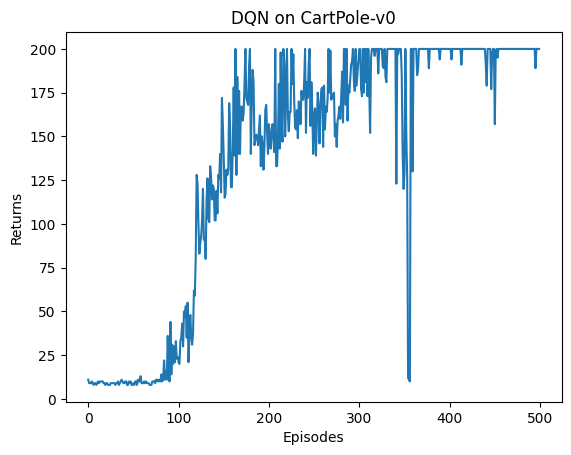

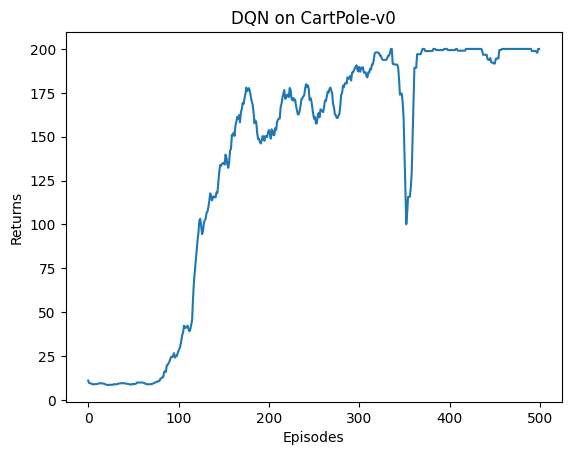

In [8]:
episodes_list = list(range(len(return_list)))
plt.plot(episodes_list, return_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('DQN on {}'.format(env_name))
plt.show()

mv_return = rl_utils.moving_average(return_list, 9)
plt.plot(episodes_list, mv_return)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('DQN on {}'.format(env_name))
plt.show()

### 保存整个网络并运行

In [9]:
# # 保存模型步骤
# torch.save(agent, 'DQN_whole.pth')  # 保存整个神经网络的模型结构以及参数用torch.save(model, path)，该方法不能换设备
# # torch.save(agent, 'net.pkl')  # 同上
# # 以下两行运行不动
# # torch.save(agent.state_dict(), 'net_params.pth')  # 只保存模型参数   torch.save(model.state_dict(), path) # 保存模型的参数
# # torch.save(agent.state_dict(), 'net_params.pkl')  # 同上

# # 加载模型步骤
# agent1 = torch.load('DQN_whole.pth')  # 加载整个神经网络的模型结构以及参数
# # agent1 = torch.load('net.pkl')  # 同上
# # agent1.load_state_dict(torch.load('net_params.pth')) # 仅加载参数
# # agent1.load_state_dict(torch.load('net_params.pkl')) # 同上



In [10]:
# # 运行一个仿真回合
# env = gym.make('CartPole-v0')
# env.seed(0)
# state = env.reset()
# episode_return = 0 # 该回合的回报
# # torch.manual_seed(0)
# state_dim = env.observation_space.shape[0] # 直接从环境获得
# action_dim = env.action_space.n # 直接从环境获得
# Agent=agent1 # agent
# for _ in range(100):
#     env.render()
#     # 在这写更新过程
#     action = Agent.take_action(state) #### **** 采取动作  agent1
#     next_state, reward, done, _ = env.step(action) # 与环境交互更新状态参数，每步新增1个reward
#     replay_buffer.add(state, action, reward, next_state, done)
#     state = next_state # 更新状态
#     episode_return += reward
#     return_list.append(episode_return)
# env.close()


### 保存网络参数并运行

In [11]:
# qnet= Qnet(state_dim, hidden_dim, action_dim)
# # 打印状态字典
# for param_tensor in qnet.state_dict():
#     print(param_tensor, "\t", qnet.state_dict()[param_tensor].size())
# # 保存Qnet参数
# # agent.save()
# torch.save(agent.q_net.state_dict(),'DQN_parameter.pth')  

In [12]:
# testmodel=Qnet(state_dim, hidden_dim, action_dim)
# testmodel.load_state_dict(torch.load('DQN_parameter.pth'))
# testmodel.eval()
# # 运行一个仿真回合
# env = gym.make('CartPole-v0')
# env.seed(0)
# state = env.reset()
# episode_return = 0 # 该回合的回报
# # torch.manual_seed(0)
# state_dim = env.observation_space.shape[0] # 直接从环境获得
# action_dim = env.action_space.n # 直接从环境获得
# for _ in range(100):
#     env.render()
#     # 在这写更新过程
#     state1 = torch.tensor([state], dtype=torch.float).to(device)
#     action = testmodel(state1).argmax().item()
# #     print(type(action)) ###########  查错
#     next_state, _, done, _ = env.step(action) # 与环境交互更新状态参数，每步新增1个reward
# #     replay_buffer.add(state, action, reward, next_state, done)
#     state = next_state # 更新状态
# #     episode_return += reward
# #     return_list.append(episode_return)
# env.close()

In [13]:
# 加图像判别的，略
class ConvolutionalQnet(torch.nn.Module):
    ''' 加入卷积层的Q网络 '''
    def __init__(self, action_dim, in_channels=4):
        super(ConvolutionalQnet, self).__init__()
        self.conv1 = torch.nn.Conv2d(in_channels, 32, kernel_size=8, stride=4)
        self.conv2 = torch.nn.Conv2d(32, 64, kernel_size=4, stride=2)
        self.conv3 = torch.nn.Conv2d(64, 64, kernel_size=3, stride=1)
        self.fc4 = torch.nn.Linear(7 * 7 * 64, 512)
        self.head = torch.nn.Linear(512, action_dim)

    def forward(self, x):
        x = x / 255
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = F.relu(self.fc4(x))
        return self.head(x)

显示图像删除!右侧空格：! [jupyter](./pictures/1.png)